# E-commerce Customer Analytics and Sales Forecasting
## Notebook 02 — Exploratory Data Analysis

### Overview

Exploratory Data Analysis (EDA) is a critical stage in the data science workflow.

In this notebook, I explore and analyze the structure, patterns, and relationships within the synthetic e-commerce dataset generated in Notebook 01.

Through visualization and statistical analysis, I aim to uncover key insights related to:

- revenue trends
- customer purchasing behavior
- product category performance
- marketing campaign effectiveness
- seasonal demand patterns

These insights will guide the next stages of the project, including feature engineering and machine learning modeling.

---

### Business Objectives

From a business perspective, this analysis aims to answer questions such as:

- How is revenue evolving over time?
- Which products and marketing channels drive the most revenue?
- How concentrated is revenue across customers?
- Are there clear seasonal patterns in demand?

Understanding these patterns helps me design effective marketing strategies and more accurate forecasting models.

---

### Datasets Used

In this notebook, I use the processed datasets generated in **Notebook 01**.

**customers.csv**

Contains demographic and behavioral attributes for each customer.

**orders.csv**

Contains transaction-level purchase data.

In [1]:
"""
Environment Setup
"""

import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

# directory for plots
FIG_DIR = "../figures/exploratory_analysis"

os.makedirs(FIG_DIR, exist_ok=True)

print("Environment initialized.")

Environment initialized.


In [2]:
"""
Load Processed Datasets
"""

customers = pd.read_csv(
    "../data/processed/customers.csv",
    parse_dates=["signup_date"]
)

orders = pd.read_csv(
    "../data/processed/orders.csv",
    parse_dates=["order_date"]
)

print("Customers:", customers.shape)
print("Orders:", orders.shape)

customers.head()

Customers: (10000, 15)
Orders: (495949, 8)


/var/folders/hr/kl__grj55kd6q86n_ksznz3r0000gn/T/ipykernel_22197/2934140134.py:10: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  orders = pd.read_csv(


,customer_id,signup_date,age,income,country,loyalty_member,website_visits,app_usage,discount_usage,engagement_score,purchase_propensity,total_orders,total_spent,average_order_value,days_since_last_purchase
0,6173,2023-01-01,38,70953,Portugal,True,8,4,False,0.206216,0.369702,47.0,4547.73,96.760213,7.0
1,7128,2023-01-03,21,42602,Spain,True,11,4,True,0.438138,0.493732,68.0,5440.13,80.001912,10.0
2,4220,2023-01-03,40,30478,France,False,12,2,True,0.546699,0.320223,40.0,3978.12,99.453000,4.0
3,1120,2023-01-04,52,22415,Portugal,True,13,1,True,0.562599,0.575448,118.0,11282.80,95.616949,2.0
4,2020,2023-01-05,51,39682,Italy,False,9,4,False,0.254583,0.136320,17.0,2259.21,132.894706,1.0


In [3]:
"""
Plot Utility
"""

def save_plot(filename):
    """
    Save current matplotlib figure to project figure directory.
    """
    
    path = os.path.join(FIG_DIR, filename)
    
    plt.tight_layout()
    plt.savefig(path, dpi=300)
    plt.show()

## Business KPIs

Before diving deeper into the analysis, I compute high-level business metrics that summarize the performance of the e-commerce platform.

These key performance indicators (KPIs) provide a quick overview of the business and help contextualize the rest of the analysis.

The following metrics are calculated:

**Platform scale**

- Total number of customers
- Total number of orders

**Revenue metrics**

- Total revenue
- Average order value

**Customer metrics**

- Average orders per customer
- Average revenue per customer

These indicators are commonly used in **e-commerce dashboards and executive reports**.

In [4]:
"""
Business KPI Calculation
"""

total_customers = customers["customer_id"].nunique()
total_orders = orders["order_id"].nunique()

total_revenue = orders["order_value"].sum()

average_order_value = orders["order_value"].mean()

orders_per_customer = (
    orders
    .groupby("customer_id")
    .size()
    .mean()
)

revenue_per_customer = (
    orders
    .groupby("customer_id")["order_value"]
    .sum()
    .mean()
)

kpis = {
    "Total Customers": total_customers,
    "Total Orders": total_orders,
    "Total Revenue": round(total_revenue,2),
    "Average Order Value": round(average_order_value,2),
    "Orders per Customer": round(orders_per_customer,2),
    "Revenue per Customer": round(revenue_per_customer,2)
}

kpis

{'Total Customers': 10000,
 'Total Orders': 495949,
 'Total Revenue': np.float64(51446433.33),
 'Average Order Value': np.float64(103.73),
 'Orders per Customer': np.float64(49.6),
 'Revenue per Customer': np.float64(5145.67)}

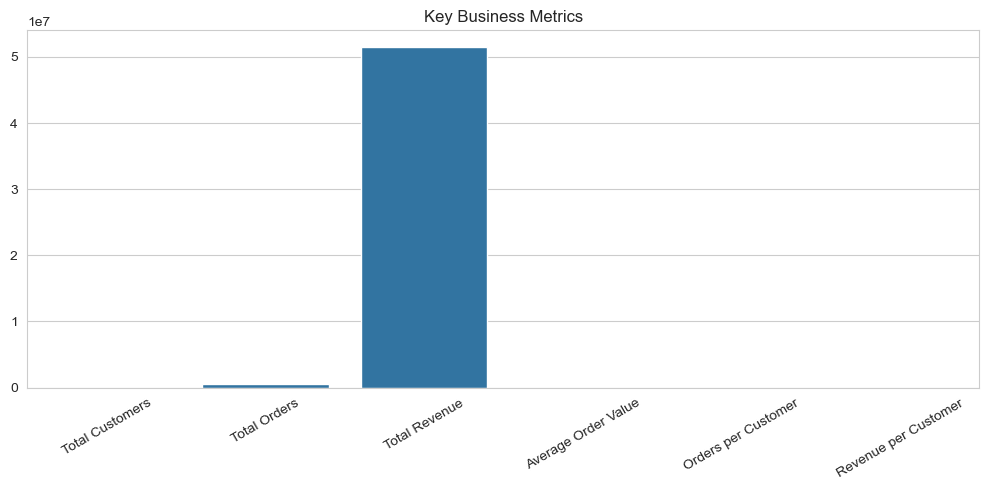

In [5]:
"""
Business KPI Visualization
"""

kpi_names = list(kpis.keys())
kpi_values = list(kpis.values())

plt.figure(figsize=(10,5))

sns.barplot(
    x=kpi_names,
    y=kpi_values
)

plt.title("Key Business Metrics")
plt.xticks(rotation=30)

save_plot("business_kpis_overview.png")

## Revenue Concentration Analysis (Pareto Principle)

In many businesses, revenue is not evenly distributed across customers.

A small fraction of customers often generates a large share of total revenue.

This phenomenon is commonly referred to as the **Pareto Principle** or **80/20 rule**, where approximately:

- 20% of customers generate 80% of revenue.

Understanding revenue concentration is important for:

- identifying high-value customers
- designing loyalty programs
- optimizing retention strategies
- prioritizing marketing investments

In this section, I analyze how revenue is distributed across customers.

In [6]:
"""
Revenue per Customer
"""

customer_revenue = (
    orders
    .groupby("customer_id")["order_value"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head()

customer_id
7029    16658.37
6121    15837.61
7798    15579.28
5163    15169.69
1115    14973.83
Name: order_value, dtype: float64

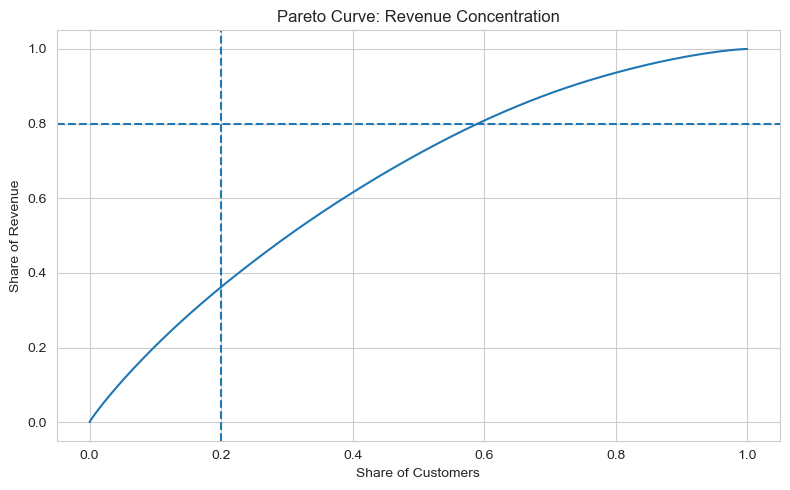

In [7]:
"""
Pareto Curve
"""

revenue_cumsum = customer_revenue.cumsum() / customer_revenue.sum()

customer_percent = np.arange(len(revenue_cumsum)) / len(revenue_cumsum)

plt.figure(figsize=(8,5))

plt.plot(customer_percent, revenue_cumsum)

plt.axhline(0.8, linestyle="--")
plt.axvline(0.2, linestyle="--")

plt.title("Pareto Curve: Revenue Concentration")
plt.xlabel("Share of Customers")
plt.ylabel("Share of Revenue")

save_plot("pareto_revenue_curve.png")

In [8]:
"""
Top Customer Revenue Share
"""

top_10_percent = int(len(customer_revenue) * 0.10)
top_20_percent = int(len(customer_revenue) * 0.20)

top10_revenue_share = (
    customer_revenue.head(top_10_percent).sum() /
    customer_revenue.sum()
)

top20_revenue_share = (
    customer_revenue.head(top_20_percent).sum() /
    customer_revenue.sum()
)

print("Revenue share of top 10% customers:", round(top10_revenue_share,3))
print("Revenue share of top 20% customers:", round(top20_revenue_share,3))

Revenue share of top 10% customers: 0.204
Revenue share of top 20% customers: 0.362


## Correlation Analysis

Understanding the relationships between variables is an important step in exploratory data analysis.

Correlation analysis helps identify how strongly variables are related to each other.

This is useful for several reasons:

- identifying useful predictors for machine learning models
- detecting redundant variables
- understanding behavioral patterns in the dataset

In this section, I analyze correlations between key numerical features in the customer dataset.

These features include demographic, behavioral, and transactional variables.

In [9]:
"""
Select Numerical Features for Correlation Analysis
"""

numeric_features = [
    "age",
    "income",
    "website_visits",
    "app_usage",
    "engagement_score",
    "purchase_propensity",
    "total_orders",
    "total_spent",
    "average_order_value",
    "days_since_last_purchase"
]

corr_data = customers[numeric_features]

corr_data.head()

,age,income,website_visits,app_usage,engagement_score,purchase_propensity,total_orders,total_spent,average_order_value,days_since_last_purchase
0,38,70953,8,4,0.206216,0.369702,47.0,4547.73,96.760213,7.0
1,21,42602,11,4,0.438138,0.493732,68.0,5440.13,80.001912,10.0
2,40,30478,12,2,0.546699,0.320223,40.0,3978.12,99.453000,4.0
3,52,22415,13,1,0.562599,0.575448,118.0,11282.80,95.616949,2.0
4,51,39682,9,4,0.254583,0.136320,17.0,2259.21,132.894706,1.0


In [10]:
"""
Compute Correlation Matrix
"""

correlation_matrix = corr_data.corr()

correlation_matrix

,age,income,website_visits,app_usage,engagement_score,purchase_propensity,total_orders,total_spent,average_order_value,days_since_last_purchase
age,1.000000,0.016457,0.006332,0.014048,0.006418,0.003554,0.007310,0.001827,-0.009561,-0.009770
income,0.016457,1.000000,0.014692,-0.004436,0.013610,0.225196,0.211972,0.204128,0.003664,-0.092723
website_visits,0.006332,0.014692,1.000000,-0.004367,0.457947,0.129393,0.125254,0.116968,-0.018712,-0.077374
app_usage,0.014048,-0.004436,-0.004367,1.000000,0.328489,0.093211,0.089441,0.084862,-0.003992,-0.071248
engagement_score,0.006418,0.013610,0.457947,0.328489,1.000000,0.642289,0.615341,0.587264,-0.003545,-0.226920
purchase_propensity,0.003554,0.225196,0.129393,0.093211,0.642289,1.000000,0.961040,0.914133,-0.006403,-0.316556
total_orders,0.007310,0.211972,0.125254,0.089441,0.615341,0.961040,1.000000,0.950119,-0.009469,-0.323092
total_spent,0.001827,0.204128,0.116968,0.084862,0.587264,0.914133,0.950119,1.000000,0.238572,-0.304843
average_order_value,-0.009561,0.003664,-0.018712,-0.003992,-0.003545,-0.006403,-0.009469,0.238572,1.000000,0.035851
days_since_last_purchase,-0.009770,-0.092723,-0.077374,-0.071248,-0.226920,-0.316556,-0.323092,-0.304843,0.035851,1.000000


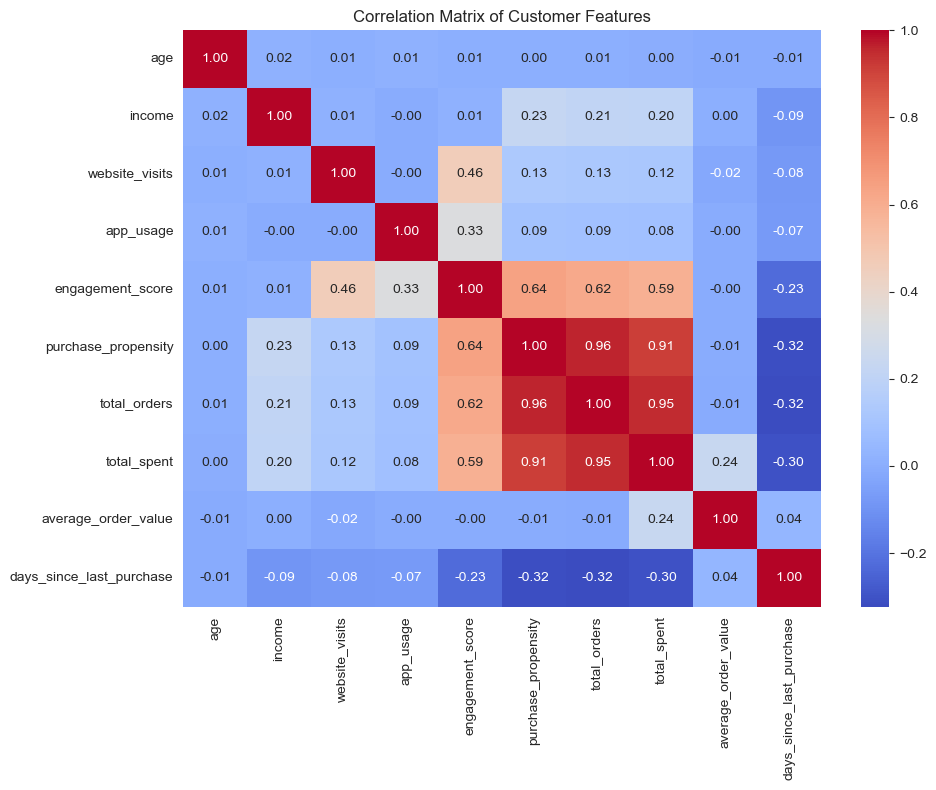

In [11]:
"""
Correlation Heatmap
"""

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Customer Features")

save_plot("customer_feature_correlation_heatmap.png")

## Customer Segment Analysis

Customers often differ significantly in terms of engagement and purchasing behavior.

Understanding these differences is important for designing effective marketing strategies and loyalty programs.

In this section, I analyze two important segmentation dimensions:

### Loyalty Membership

Customers enrolled in loyalty programs often show higher purchase frequency and spending levels.

### Engagement Levels

Customers with higher engagement with the platform (website visits, app usage) may be more likely to purchase.

By comparing these groups, I can identify behavioral patterns that will later be explored through clustering models.

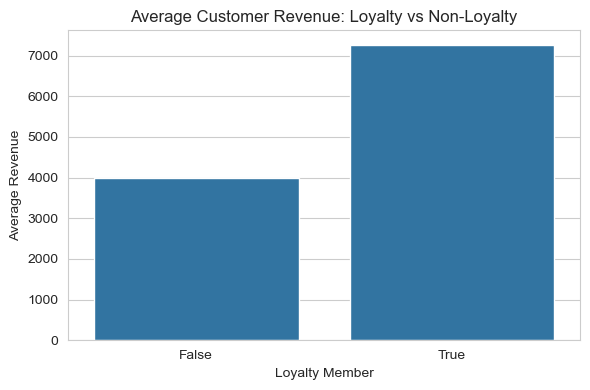

In [12]:
"""
Revenue Comparison: Loyalty vs Non-Loyalty Customers
"""

customer_revenue = (
    orders
    .groupby("customer_id")["order_value"]
    .sum()
)

customers_with_revenue = customers.merge(
    customer_revenue,
    on="customer_id",
    how="left"
)

customers_with_revenue["order_value"] = customers_with_revenue["order_value"].fillna(0)

loyalty_revenue = (
    customers_with_revenue
    .groupby("loyalty_member")["order_value"]
    .mean()
)

plt.figure(figsize=(6,4))

sns.barplot(
    x=loyalty_revenue.index.astype(str),
    y=loyalty_revenue.values
)

plt.title("Average Customer Revenue: Loyalty vs Non-Loyalty")
plt.xlabel("Loyalty Member")
plt.ylabel("Average Revenue")

save_plot("loyalty_vs_non_loyalty_revenue.png")

In [13]:
"""
Create Engagement Groups
"""

customers_with_revenue["engagement_group"] = pd.qcut(
    customers_with_revenue["engagement_score"],
    q=3,
    labels=["Low Engagement","Medium Engagement","High Engagement"]
)

customers_with_revenue.head()

,customer_id,signup_date,age,income,country,loyalty_member,website_visits,app_usage,discount_usage,engagement_score,purchase_propensity,total_orders,total_spent,average_order_value,days_since_last_purchase,order_value,engagement_group
0,6173,2023-01-01,38,70953,Portugal,True,8,4,False,0.206216,0.369702,47.0,4547.73,96.760213,7.0,4547.73,Low Engagement
1,7128,2023-01-03,21,42602,Spain,True,11,4,True,0.438138,0.493732,68.0,5440.13,80.001912,10.0,5440.13,High Engagement
2,4220,2023-01-03,40,30478,France,False,12,2,True,0.546699,0.320223,40.0,3978.12,99.453000,4.0,3978.12,High Engagement
3,1120,2023-01-04,52,22415,Portugal,True,13,1,True,0.562599,0.575448,118.0,11282.80,95.616949,2.0,11282.80,High Engagement
4,2020,2023-01-05,51,39682,Italy,False,9,4,False,0.254583,0.136320,17.0,2259.21,132.894706,1.0,2259.21,Low Engagement


/var/folders/hr/kl__grj55kd6q86n_ksznz3r0000gn/T/ipykernel_22197/3267498366.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("engagement_group")["order_value"]


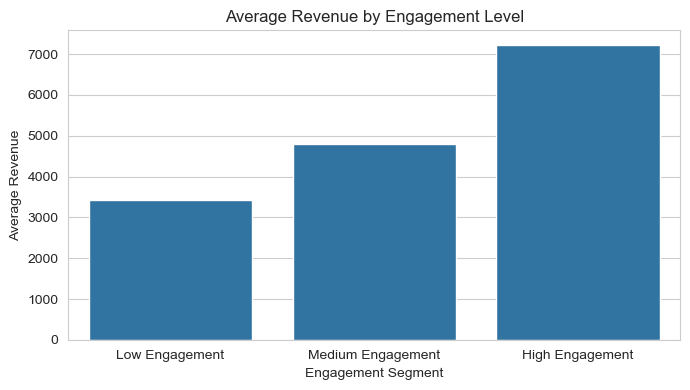

In [14]:
"""
Revenue by Engagement Segment
"""

engagement_revenue = (
    customers_with_revenue
    .groupby("engagement_group")["order_value"]
    .mean()
)

plt.figure(figsize=(7,4))

sns.barplot(
    x=engagement_revenue.index,
    y=engagement_revenue.values
)

plt.title("Average Revenue by Engagement Level")
plt.xlabel("Engagement Segment")
plt.ylabel("Average Revenue")

save_plot("revenue_by_engagement_segment.png")

## Data Dictionary

A data dictionary provides documentation for all variables in a dataset.

It typically includes information such as:

- column name
- data type
- description of the variable

Maintaining a data dictionary is a common best practice in data science and analytics projects, as it improves dataset transparency and usability.

In this section, I automatically generate a basic data dictionary for both datasets used in this project.

In [15]:
"""
Generate Data Dictionary
"""

customer_dict = pd.DataFrame({
    "column_name": customers.columns,
    "data_type": customers.dtypes.values
})

order_dict = pd.DataFrame({
    "column_name": orders.columns,
    "data_type": orders.dtypes.values
})

print("Customer Dataset Dictionary")
display(customer_dict)

print("\nOrders Dataset Dictionary")
display(order_dict)

Customer Dataset Dictionary


,column_name,data_type
0,customer_id,int64
1,signup_date,datetime64[ns]
2,age,int64
3,income,int64
4,country,object
5,loyalty_member,bool
6,website_visits,int64
7,app_usage,int64
8,discount_usage,bool
9,engagement_score,float64



Orders Dataset Dictionary


,column_name,data_type
0,order_id,int64
1,customer_id,int64
2,order_date,datetime64[ns]
3,promotion,bool
4,holiday,object
5,product_category,object
6,order_value,float64
7,marketing_campaign,object


In [16]:
"""
Export Data Dictionary
"""

customer_dict.to_csv(
    "../data/processed/customers_data_dictionary.csv",
    index=False
)

order_dict.to_csv(
    "../data/processed/orders_data_dictionary.csv",
    index=False
)

print("Data dictionaries exported successfully.")

Data dictionaries exported successfully.
